Imports

In [6]:
import os

import ipywidgets as widgets
import pandas as pd

import plotly.graph_objects as go
from modelon.impact.client import Client

Setup Modelon Impact Client

In [7]:
client = Client()
workspaceid = 'impactvoilaappexample'
workspace = client.get_workspace(workspaceid)
dynamic = workspace.get_custom_function('dynamic')

Experiment Setup

In [3]:
model_name = 'ElectricRange.Experiments.Range2'
battery = ".ElectricRange.Batteries.BatteryA"
mass = 2050
model_name_with_redeclare = f"{model_name}(redeclare replaceable {battery} batteryPack)"
model_with_redeclares = workspace.get_model(model_name_with_redeclare)
modifiers = { "chassis.vehicle_mass": mass }
experiment_definition_base = model_with_redeclares.new_experiment_definition(dynamic.with_parameters(start_time=0, final_time=36000))
experiment_definition = experiment_definition_base.with_modifiers(modifiers)

Execute experiment

In [8]:
experiment = workspace.execute(experiment_definition).wait()

Plot the results

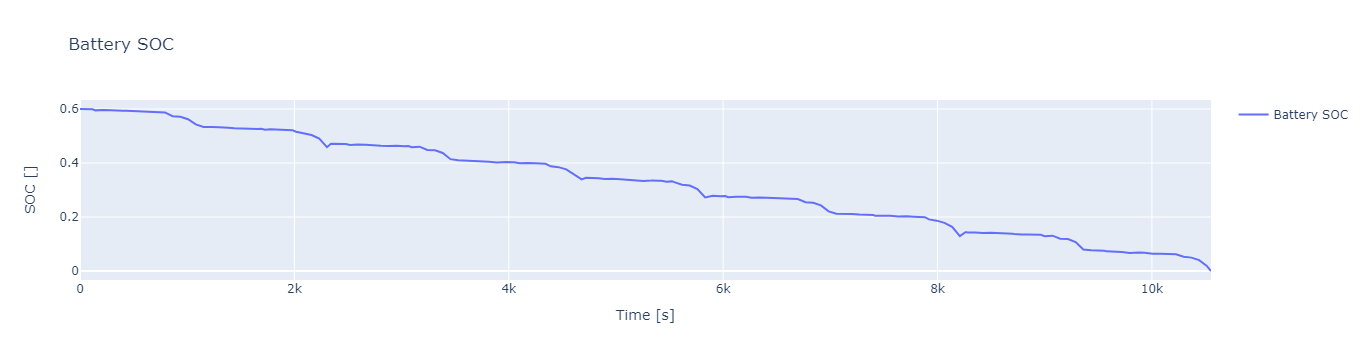

In [9]:
case = experiment.get_cases()[0]
res = case.get_trajectories()

fig = go.Figure()
fig.add_trace(go.Scatter(x=res["time"], y=res["batteryPack.summary.SoC"], name="Battery SOC", mode='lines'))
fig.update_layout(xaxis_title='Time [s]', yaxis_title='SOC []', title='Battery SOC', showlegend=True)
fig.show()